# Analysis of MNase-seq replication timing

March 25, 2024

This notebook aims to examine the raw MNase-seq data and compare to the Brewer replication timing.



In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [167]:
from cc_src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [172]:
mnase_analysis = MNaseOriginAnalysis()

In [224]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [225]:
mnase_analysis.compute_sliding_window_counts_all_times(10000, 2000)

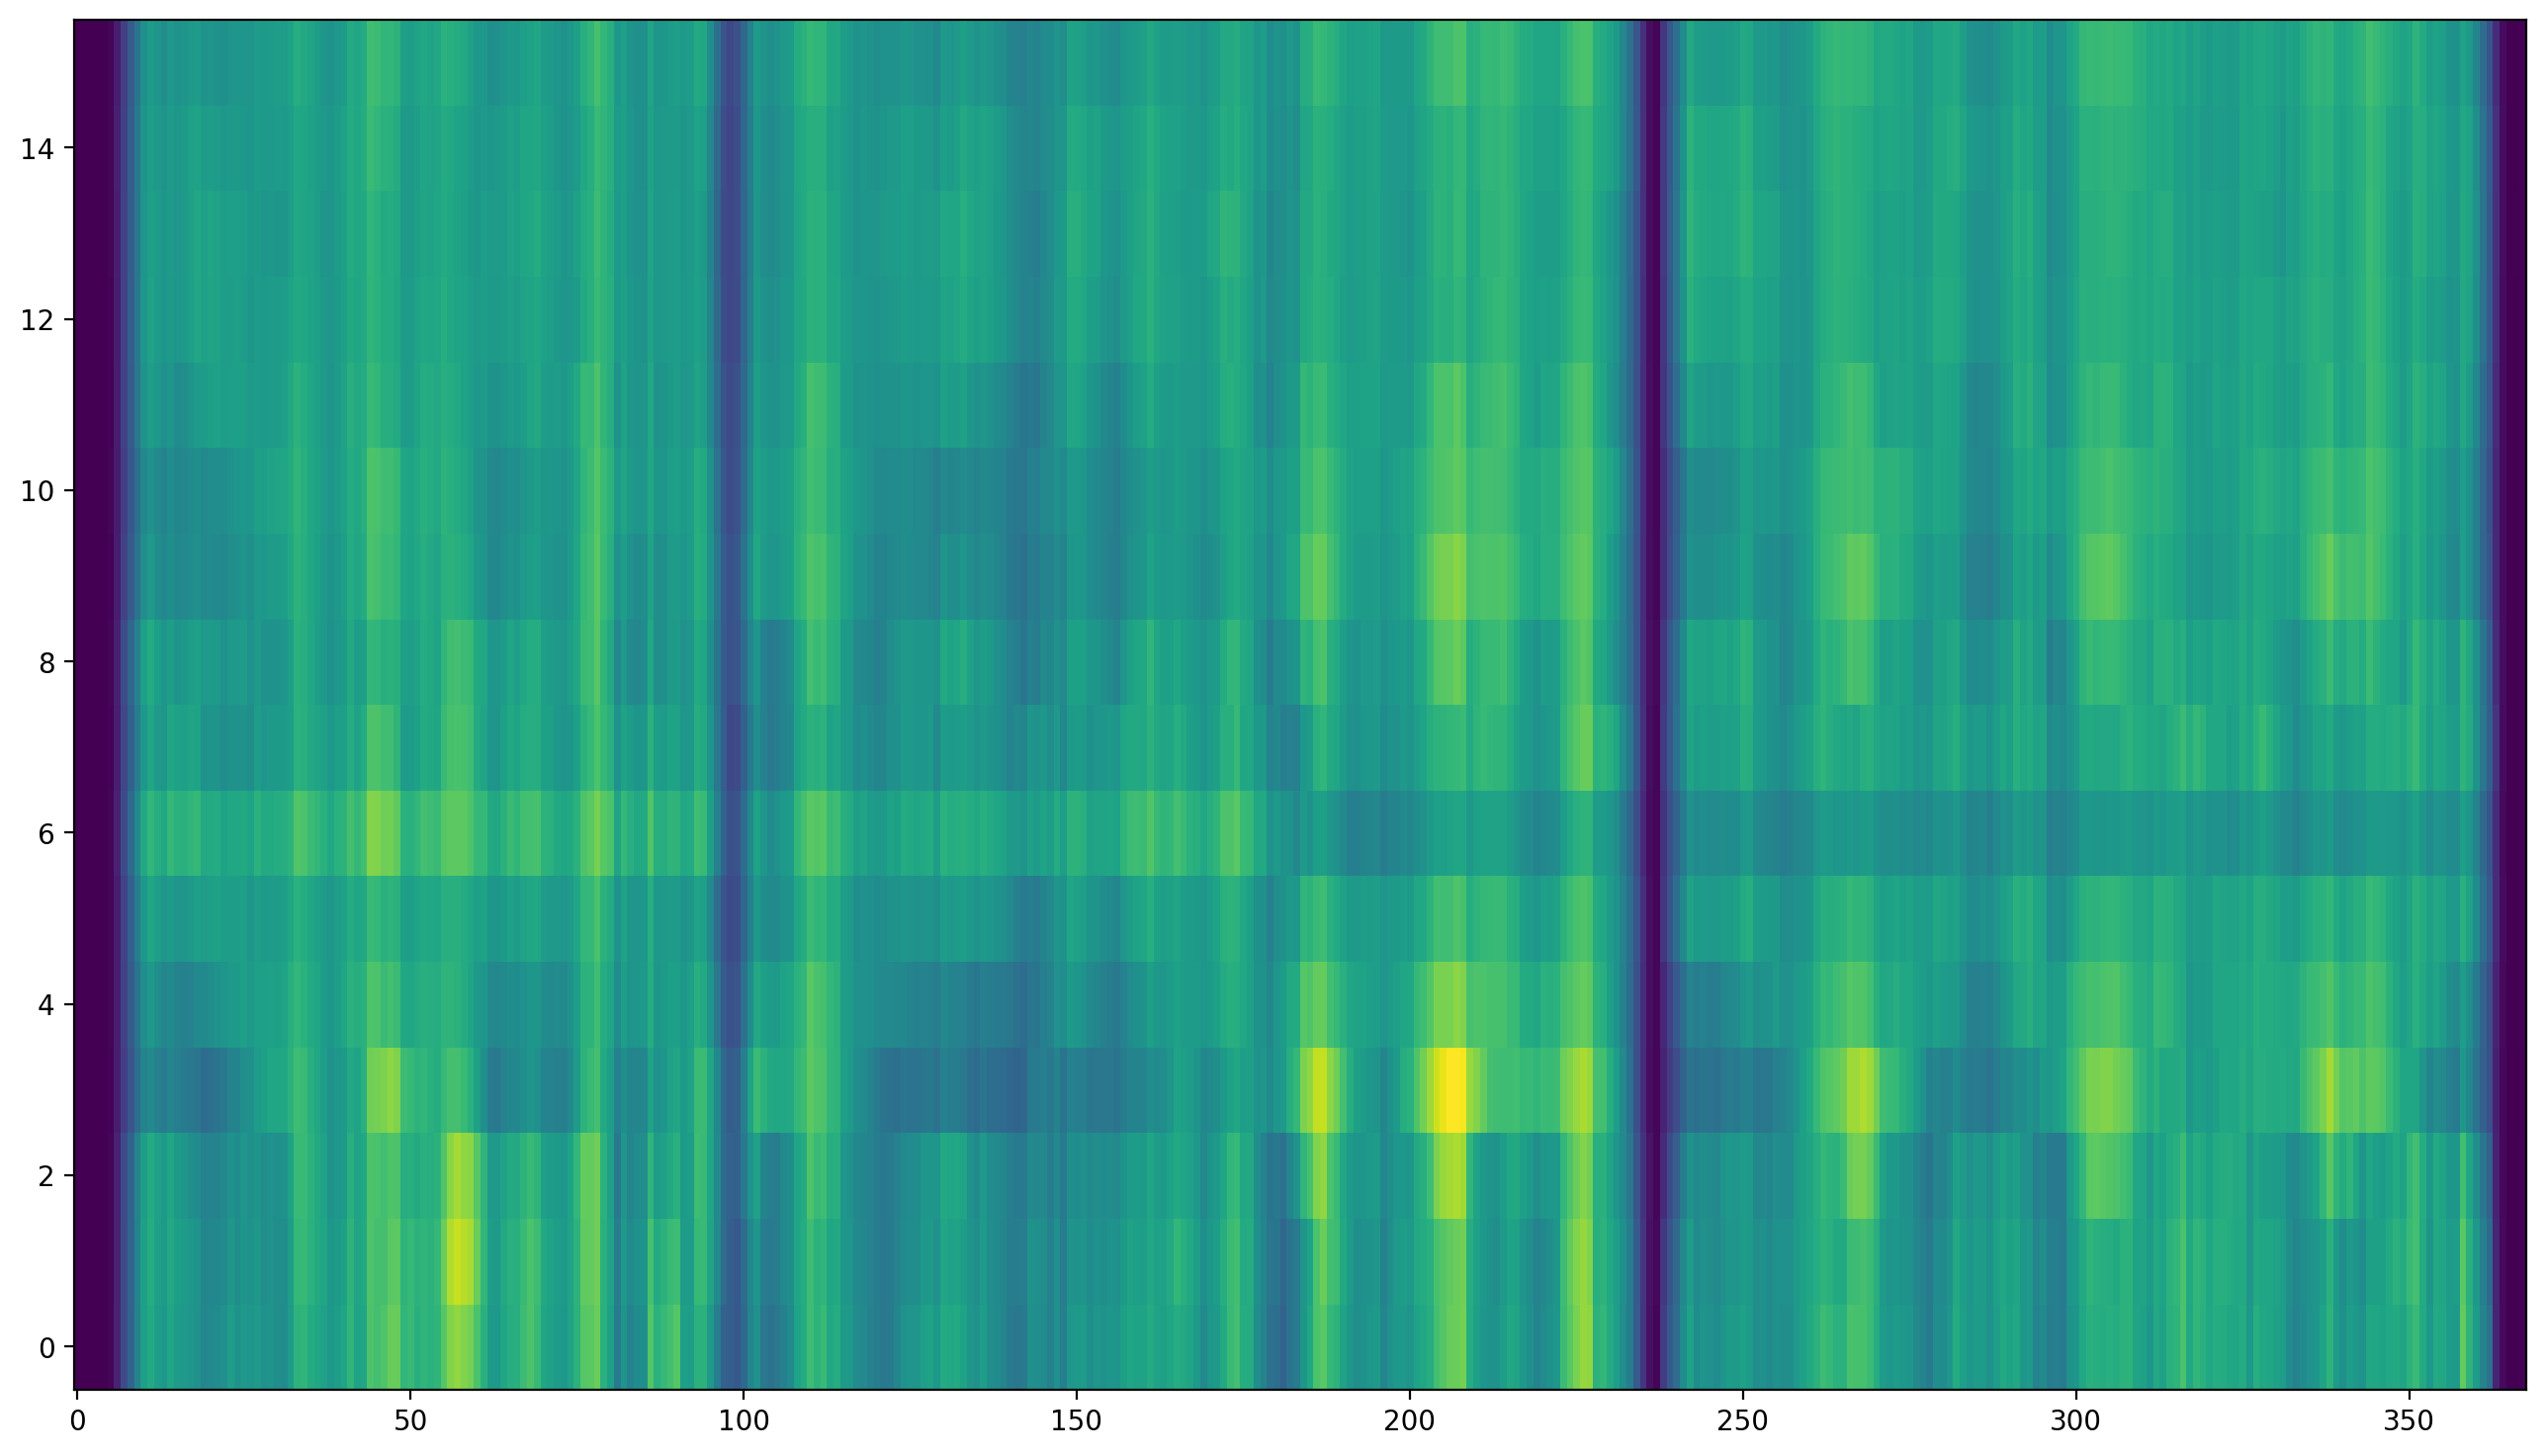

In [238]:
sum_per_time = mnase_analysis.all_window_counts.sum(axis=1)
sample_normalized = mnase_analysis.all_window_counts / \
    sum_per_time.reshape((sum_per_time.shape[0], 1))

plt.figure(figsize=(16, 9))
plt.imshow(sample_normalized, aspect='auto', origin='lower')